# Smart Fund Advisor — Notebook 4: Mutual Fund Recommendation Engine (v2)

**Objective:**  
Build and evaluate the **central** mutual fund recommendation engine.

### Why Central?
- The **risk model** is private — lives on device, trained via federated learning.
- The **recommendation model** uses only the **risk tier** (a non-identifying label)  
  so it can safely remain on the central server.

### Recommendation Logic (v2)
```
Risk Tier (device prediction via 15-feature RiskMLP)
       ↓
Scheme_Category keyword filter  (5-tier lookup table)
       ↓
Ensemble scoring: 0.40 × XGBoost + 0.35 × Random Forest + 0.25 × LightGBM
       ↓
Portfolio allocation with AMC concentration cap (40%) + HHI diversification
       ↓
Top-N funds with GPT-powered explanations
```

**Risk → Fund Category Mapping**
| Risk Tier | Fund Categories |
|-----------|----------------|
| Very Low  | Liquid, Overnight, Ultra Short, Money Market |
| Low       | Short Duration, Banking & PSU, Corporate Bond |
| Medium    | Balanced Advantage, Hybrid, Multi Asset |
| High      | Large Cap, Flexi Cap, Large & Mid Cap |
| Very High | Mid Cap, Small Cap, ELSS, Sectoral, Index |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import RISK_CLASSES, TOP_N_RECOMMENDATIONS, RISK_TO_FUND_CATEGORIES
from src.recommender import load_mutual_funds, recommend_funds

mf_df = load_mutual_funds()
print(f'Mutual fund catalogue loaded: {len(mf_df)} funds')
mf_df[['Scheme_Name','Scheme_Category','risk_tier','NAV','Average_AUM_Cr']].head(5)

Mutual fund catalogue loaded: 14270 funds


,Scheme_Name,Scheme_Category,risk_tier,NAV,Average_AUM_Cr
0,Aditya Birla Sun Life Large & Mid Cap Fund,Equity Scheme - Large & Mid Cap Fund,Medium,918.5400,4555.9612
1,Aditya Birla Sun Life Large & Mid Cap Fund,Equity Scheme - Large & Mid Cap Fund,High,133.7800,487.7777
2,Aditya Birla Sun Life Income Fund,Debt Scheme - Medium to Long Duration Fund,High,13.1256,11.4141
3,Aditya Birla Sun Life Income Fund,Debt Scheme - Medium to Long Duration Fund,Medium,127.0718,817.0224
4,Aditya Birla Sun Life Liquid Fund,Debt Scheme - Liquid Fund,Low,108.0230,0.2130


In [2]:
# ── 1. Coverage check: how many funds map to each tier? ──
tier_counts = mf_df['risk_tier'].value_counts(dropna=True)
print('Fund count per risk tier:')
print(tier_counts)

uncovered = mf_df['risk_tier'].isna().sum()
print(f'\nFunds not mapped to any tier: {uncovered} ({uncovered/len(mf_df)*100:.1f}%)')

Fund count per risk tier:
risk_tier
Low          6393
Medium       3162
High         3028
Very_Low      863
Very_High     824
Name: count, dtype: int64

Funds not mapped to any tier: 0 (0.0%)


---
## Fund Catalogue — Data Preparation Detail

Before any risk-tier assignment or ensemble scoring, the catalogue goes through several preparation steps that are not visible from the high-level outputs. The cells below document:

1. **Missing value rates** in key catalogue columns and their treatment
2. **Boolean flags** derived from `Scheme_Type`, `Scheme_NAV_Name`, `Closure_Date`
3. **AMC frequency encoding** (`amc_size_norm`) used as a model feature
4. **Risk tier source breakdown** — how many funds get their tier from NAV history vs. keyword fallback
5. **CATEGORY_RISK_BOUNDS clamp** — how many funds have their statistically-derived tier overridden by SEBI-aligned floor/ceiling rules


In [3]:

# ── DP-1. Missing value analysis + boolean flag engineering ───────────────────
import pandas as pd
import numpy as np
import os

raw_mf_path = os.path.join('Data', 'mutual_fund_data.csv')
raw_mf = pd.read_csv(raw_mf_path, low_memory=False)
raw_mf.columns = [c.strip() for c in raw_mf.columns]

print(f"Raw catalogue: {len(raw_mf):,} rows × {raw_mf.shape[1]} columns")
print()

# Missing values
missing = raw_mf.isnull().sum()
missing_pct = 100 * missing / len(raw_mf)
mf_miss = pd.DataFrame({'Count': missing[missing > 0],
                         'Pct_%': missing_pct[missing > 0].round(2)}).sort_values('Pct_%', ascending=False)
print("=== Missing Values — Raw Fund Catalogue ===")
print(mf_miss.to_string())

# Rows dropped for invalid NAV
nav_num = pd.to_numeric(raw_mf['NAV'], errors='coerce')
dropped_nav = nav_num.isna().sum()
print(f"\nRows dropped (null/non-numeric NAV): {dropped_nav:,} ({100*dropped_nav/len(raw_mf):.2f}%)")
print(f"Rows retained after NAV filter:      {len(raw_mf) - dropped_nav:,}")

# Engineer and inspect boolean flags
df_flags = raw_mf.copy()
df_flags['NAV_num']      = pd.to_numeric(df_flags['NAV'], errors='coerce')
df_flags                 = df_flags[df_flags['NAV_num'].notna()].copy()
df_flags['Closure_Date'] = pd.to_datetime(df_flags['Closure_Date'], errors='coerce')
df_flags['is_open_ended'] = df_flags['Scheme_Type'].str.contains('Open', case=False, na=False).astype(int)
df_flags['is_active']     = df_flags['Closure_Date'].isna().astype(int)
df_flags['is_growth']     = df_flags.get('Scheme_NAV_Name', pd.Series([''] * len(df_flags))).fillna('').str.contains('Growth', case=False, na=False).astype(int)

print("\n=== Boolean Flag Summary ===")
print(f"  is_open_ended = 1 (Open-ended schemes): "
      f"{df_flags['is_open_ended'].sum():,} ({100*df_flags['is_open_ended'].mean():.1f}%)")
print(f"  is_active     = 1 (No closure date):    "
      f"{df_flags['is_active'].sum():,} ({100*df_flags['is_active'].mean():.1f}%)")
print(f"  is_growth     = 1 (Growth NAV option):  "
      f"{df_flags['is_growth'].sum():,} ({100*df_flags['is_growth'].mean():.1f}%)")


Raw catalogue: 16,346 rows × 16 columns

=== Missing Values — Raw Fund Catalogue ===
                                         Count  Pct_%
Closure_Date                             12489  76.40
Average_AUM_Cr                            8306  50.81
AAUM_Quarter                              8306  50.81
NAV                                       2076  12.70
Latest_NAV_Date                           2076  12.70
ISIN_Div_Payout/Growth                    2076  12.70
ISIN_Div_Reinvestment                     2076  12.70
ISIN_Div_Payout/Growth/Div_Reinvestment   1410   8.63
Scheme_Min_Amt                              30   0.18
Launch_Date                                 21   0.13

Rows dropped (null/non-numeric NAV): 2,076 (12.70%)
Rows retained after NAV filter:      14,270

=== Boolean Flag Summary ===
  is_open_ended = 1 (Open-ended schemes): 9,277 (65.0%)
  is_active     = 1 (No closure date):    10,671 (74.8%)
  is_growth     = 1 (Growth NAV option):  5,210 (36.5%)


=== AMC Frequency Encoding (amc_size_norm) ===
Top 15 AMCs: count  amc_size_norm (used as a model feature)
────────────────────────────────────────────────────────────
  ICICI Prudential Asset Management Company Limited 2488  1.000  ██████████████████████████████
  Nippon Life India Asset Management Limited 1908  0.767  ███████████████████████
  UTI Asset Mgmt. Co. Ltd.                   1360  0.547  ████████████████
  Kotak Mahindra Asset Management Company Limited.  887  0.357  ██████████
  HDFC Asset Management Company Limited       564  0.227  ██████
  SBI Funds Management Limited                509  0.205  ██████
  Franklin Templeton Asset Management (India) Private Limited  476  0.191  █████
  Aditya Birla Sun Life AMC Limited           475  0.191  █████
  Bandhan AMC Limited                         431  0.173  █████
  Axis Asset Management Co. Ltd.              411  0.165  ████
  Tata Asset Management Limited               395  0.159  ████
  DSP Asset Managers Private Limited   

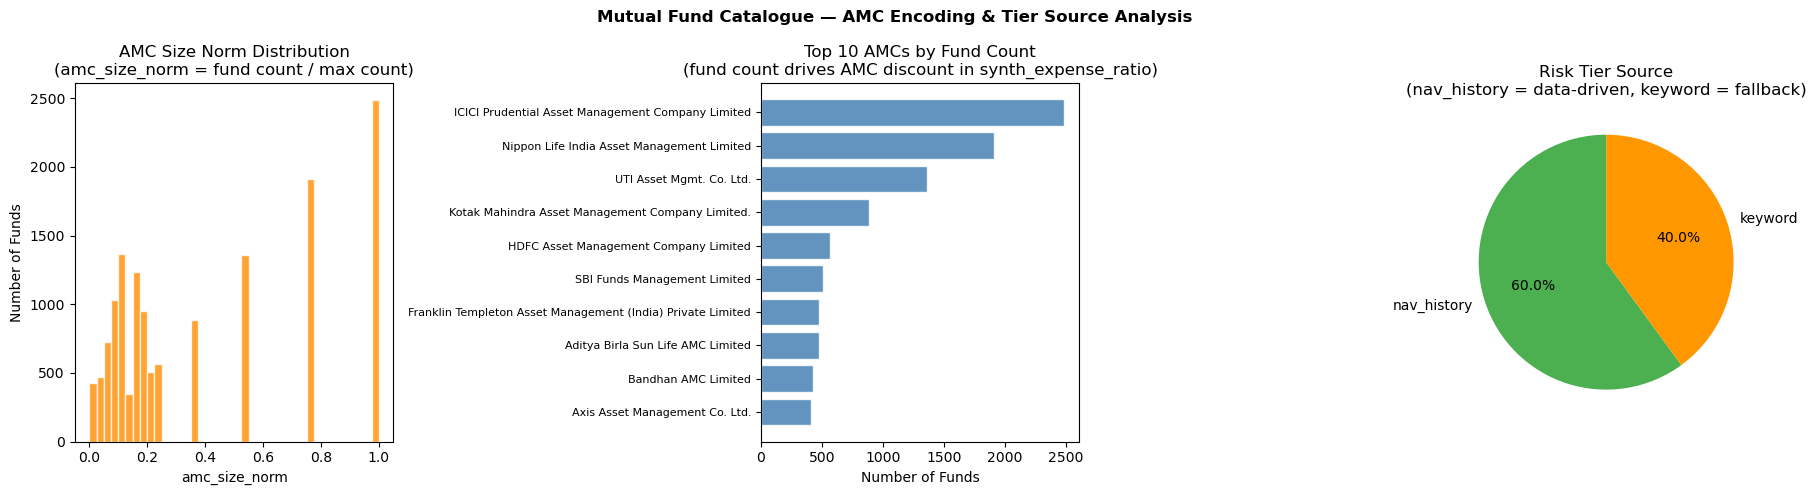

✓ Saved → models/plot_mf_amc_encoding.png


In [4]:

# ── DP-2. AMC frequency encoding & risk_tier_source breakdown ─────────────────
import matplotlib.pyplot as plt

# AMC frequency encoding (from build_fund_features)
amc_s      = mf_df['AMC'].fillna('Other')
amc_counts = amc_s.value_counts()
amc_norm   = amc_counts / amc_counts.max()

print("=== AMC Frequency Encoding (amc_size_norm) ===")
print("Top 15 AMCs: count  amc_size_norm (used as a model feature)")
print("─" * 60)
for amc, cnt in amc_counts.head(15).items():
    norm = cnt / amc_counts.max()
    bar_vis = '█' * int(norm * 30)
    print(f"  {amc:<42} {cnt:4d}  {norm:.3f}  {bar_vis}")

# amc_is_top flag
top_amcs = amc_counts.head(15).index.tolist()
amc_is_top = amc_s.isin(top_amcs)
print(f"\n  amc_is_top = 1 (top 15 AMCs): {amc_is_top.sum():,} funds "
      f"({100*amc_is_top.mean():.1f}%)")
print(f"  amc_is_top = 0 (other AMCs):  {(~amc_is_top).sum():,} funds "
      f"({100*(~amc_is_top).mean():.1f}%)")

# Risk tier source breakdown
if 'risk_tier_source' in mf_df.columns:
    print("\n=== Risk Tier Source Breakdown ===")
    src_counts = mf_df['risk_tier_source'].value_counts()
    for src, cnt in src_counts.items():
        print(f"  {src:<20}: {cnt:5,} funds ({100*cnt/len(mf_df):.1f}%)")
else:
    print("\n  (risk_tier_source column not present — rerun load_mutual_funds())")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mutual Fund Catalogue — AMC Encoding & Tier Source Analysis", fontsize=12, fontweight='bold')

# (1) AMC size norm distribution
ax = axes[0]
ax.hist(amc_s.map(amc_counts).fillna(1) / amc_counts.max(), bins=40,
        color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title("AMC Size Norm Distribution\n(amc_size_norm = fund count / max count)")
ax.set_xlabel("amc_size_norm"); ax.set_ylabel("Number of Funds")

# (2) Top 10 AMCs by fund count
ax = axes[1]
top10 = amc_counts.head(10)
ax.barh(top10.index[::-1], top10.values[::-1], color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title("Top 10 AMCs by Fund Count\n(fund count drives AMC discount in synth_expense_ratio)")
ax.set_xlabel("Number of Funds")
ax.tick_params(axis='y', labelsize=8)

# (3) Risk tier source pie
ax = axes[2]
if 'risk_tier_source' in mf_df.columns:
    src_pie = mf_df['risk_tier_source'].value_counts()
    ax.pie(src_pie.values, labels=src_pie.index, autopct='%1.1f%%',
           colors=['#4CAF50', '#FF9800'], startangle=90)
    ax.set_title("Risk Tier Source\n(nav_history = data-driven, keyword = fallback)")
else:
    ax.text(0.5, 0.5, "risk_tier_source\nnot available",
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Risk Tier Source")

plt.tight_layout()
save_path = os.path.join('models', 'plot_mf_amc_encoding.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


=== CATEGORY_RISK_BOUNDS — Impact per Category ===
Category                      Funds  Floor        Ceiling       At Floor  At Ceiling
─────────────────────────────────────────────────────────────────────────────────────
  index                       1,257  Medium       Very_High          740         271
  thematic                      996  High         Very_High          771         225
  sectoral                      996  High         Very_High          771         225
  short duration                544  Low          Medium             311         113
  fof domestic                  520  Medium       High               328         192
  liquid                        490  Very_Low     Low                166         324
  etf                           320  Medium       Very_High          187          66
  overnight                     298  Very_Low     Very_Low           298         298
  ultra short                   294  Very_Low     Low                120         174
  elss       

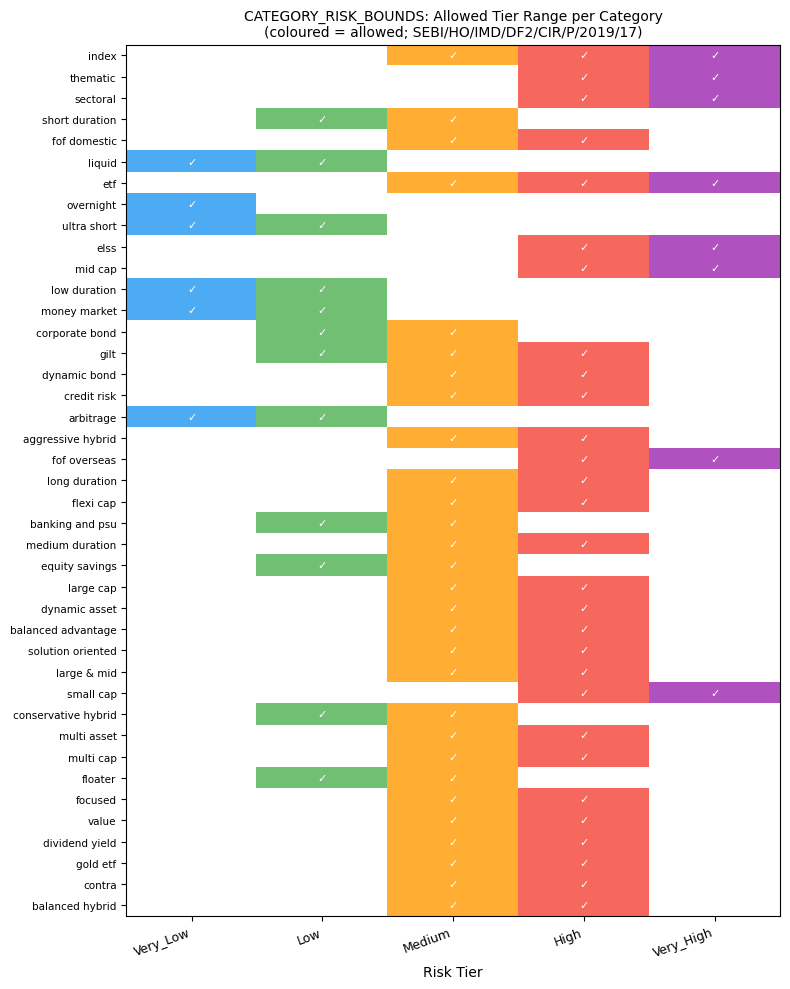

✓ Saved → models/plot_mf_category_bounds.png


In [5]:

# ── DP-3. CATEGORY_RISK_BOUNDS — SEBI floor/ceiling clamp impact ──────────────
# After compute_fund_risk_bands() assigns tiers from NAV vol/drawdown percentiles,
# config.CATEGORY_RISK_BOUNDS clamps each fund to SEBI-mandated min/max tiers.
# This cell quantifies how many funds have their tier overridden by the clamp.
# Reference: SEBI Circular SEBI/HO/IMD/DF2/CIR/P/2019/17 — product risk-o-meter.

from config import CATEGORY_RISK_BOUNDS, RISK_CLASSES as RC

tier_ord_map = {r: i for i, r in enumerate(RC)}
mf_df_check  = mf_df.copy()
mf_df_check['tier_ord'] = mf_df_check['risk_tier'].map(tier_ord_map)
cat_col = mf_df_check['Scheme_Category'].fillna('')

# Count clamped funds per bounds category
clamp_summary = []
for cat_kw, (fl, ce) in CATEGORY_RISK_BOUNDS.items():
    mask = cat_col.str.lower().str.contains(cat_kw, na=False)
    n_total = mask.sum()
    if n_total == 0:
        continue
    n_floor_bound   = (mf_df_check.loc[mask, 'tier_ord'] == fl).sum()
    n_ceiling_bound = (mf_df_check.loc[mask, 'tier_ord'] == ce).sum()
    allowed_spread  = ce - fl
    clamp_summary.append({
        'Category': cat_kw,
        'Funds':    n_total,
        'Floor': RC[fl], 'Ceiling': RC[ce],
        'Tier_Spread': allowed_spread,
        'At_Floor': n_floor_bound,
        'At_Ceiling': n_ceiling_bound,
    })

cs_df = pd.DataFrame(clamp_summary).sort_values('Funds', ascending=False)
print("=== CATEGORY_RISK_BOUNDS — Impact per Category ===")
print(f"{'Category':<28} {'Funds':>6}  {'Floor':<12} {'Ceiling':<12} {'At Floor':>9}  {'At Ceiling':>10}")
print("─" * 85)
for _, row in cs_df.iterrows():
    print(f"  {row['Category']:<26} {row['Funds']:>6,}  {row['Floor']:<12} {row['Ceiling']:<12} "
          f"{row['At_Floor']:>9,}  {row['At_Ceiling']:>10,}")

# Three-way tier source comparison
if 'risk_tier_source' in mf_df.columns:
    nav_driven  = (mf_df['risk_tier_source'] == 'nav_history').sum()
    kw_fallback = (mf_df['risk_tier_source'] == 'keyword').sum()
    print(f"\n=== Overall Tier Assignment Summary ===")
    print(f"  Data-driven (NAV history + SEBI clamp): {nav_driven:,}  ({100*nav_driven/len(mf_df):.1f}%)")
    print(f"  Keyword fallback (no NAV history):       {kw_fallback:,}  ({100*kw_fallback/len(mf_df):.1f}%)")
    print(f"  Unmapped (null risk_tier):               {mf_df['risk_tier'].isna().sum():,}")

# Visualise tier spread (floor → ceiling) as a heatmap
fig, ax = plt.subplots(figsize=(8, 10))
n_bounds = len(cs_df)
hmap = np.full((n_bounds, 5), np.nan)

for i, (_, row) in enumerate(cs_df.iterrows()):
    fl = RC.index(row['Floor'])
    ce = RC.index(row['Ceiling'])
    for t in range(fl, ce + 1):
        hmap[i, t] = 1

tier_colors_arr = np.zeros((n_bounds, 5, 4))
tier_rgba = {
    0: [0.13, 0.59, 0.95, 0.8],  # Very_Low  blue
    1: [0.30, 0.69, 0.31, 0.8],  # Low       green
    2: [1.00, 0.60, 0.00, 0.8],  # Medium    orange
    3: [0.96, 0.26, 0.21, 0.8],  # High      red
    4: [0.61, 0.15, 0.69, 0.8],  # Very_High purple
}
for i in range(n_bounds):
    for t in range(5):
        if not np.isnan(hmap[i, t]):
            tier_colors_arr[i, t] = tier_rgba[t]

ax.imshow(tier_colors_arr, aspect='auto', origin='upper')
ax.set_xticks(range(5))
ax.set_xticklabels(RC, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(n_bounds))
ax.set_yticklabels(cs_df['Category'].tolist(), fontsize=7.5)
ax.set_title("CATEGORY_RISK_BOUNDS: Allowed Tier Range per Category\n"
             "(coloured = allowed; SEBI/HO/IMD/DF2/CIR/P/2019/17)", fontsize=10)
ax.set_xlabel("Risk Tier")
for i in range(n_bounds):
    for t in range(5):
        if not np.isnan(hmap[i, t]):
            ax.text(t, i, f"✓", ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
save_path = os.path.join('models', 'plot_mf_category_bounds.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


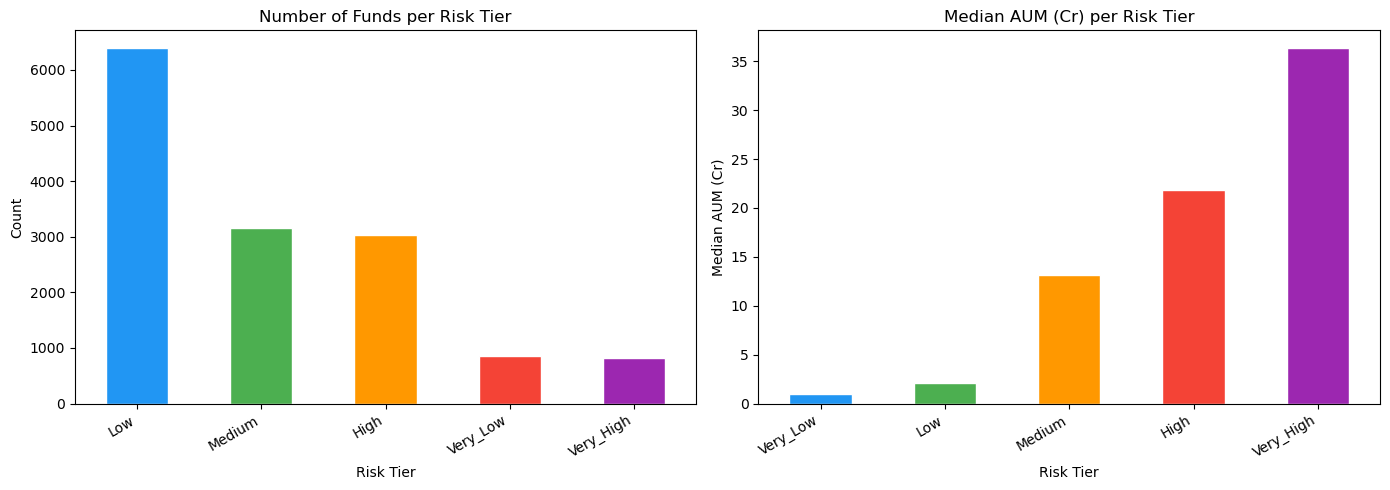

In [6]:
# ── 2. Visualise tier coverage ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Count bar
tier_counts.plot(kind='bar', ax=axes[0],
                 color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'],
                 edgecolor='white')
axes[0].set_title('Number of Funds per Risk Tier')
axes[0].set_xlabel('Risk Tier'); axes[0].set_ylabel('Count')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# b) Avg AUM per tier
aum_tier = mf_df.dropna(subset=['risk_tier','Average_AUM_Cr']).groupby('risk_tier')['Average_AUM_Cr'].median()
aum_tier.reindex(RISK_CLASSES).plot(kind='bar', ax=axes[1],
                                    color=['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0'],
                                    edgecolor='white')
axes[1].set_title('Median AUM (Cr) per Risk Tier')
axes[1].set_xlabel('Risk Tier'); axes[1].set_ylabel('Median AUM (Cr)')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('models/plot_mf_tier_stats.png', dpi=150)
plt.show()

In [7]:
# ── 3. Demo: Get top-5 recommendations for each risk tier ──
for tier in RISK_CLASSES:
    print(f'\n{"-"*70}')
    print(f'  Risk Tier: {tier}')
    print(f'{"-"*70}')
    recs = recommend_funds(tier, mf_df, top_n=TOP_N_RECOMMENDATIONS)
    if recs.empty:
        print('  No funds found for this tier.')
    else:
        display_cols = ['Scheme_Name', 'AMC', 'Scheme_Category', 'NAV', 'Average_AUM_Cr', 'score']
        display_cols = [c for c in display_cols if c in recs.columns]
        print(recs[display_cols].to_string(index=False))


----------------------------------------------------------------------
  Risk Tier: Very_Low
----------------------------------------------------------------------


                           Scheme_Name                                               AMC                         Scheme_Category      NAV  Average_AUM_Cr    score
ICICI Prudential Ultra Short term Fund ICICI Prudential Asset Management Company Limited Debt Scheme - Ultra Short Duration Fund  16.0996             NaN 0.269483
         ICICI Prudential Savings Fund ICICI Prudential Asset Management Company Limited         Debt Scheme - Low Duration Fund 100.9560             NaN 0.269453
Nippon India Ultra Short Duration Fund        Nippon Life India Asset Management Limited Debt Scheme - Ultra Short Duration Fund   0.0000             NaN 0.263673
Nippon India Ultra Short Duration Fund        Nippon Life India Asset Management Limited Debt Scheme - Ultra Short Duration Fund   0.0000             NaN 0.263673
              Kotak Treasury Advantage  Kotak Mahindra Asset Management Company Limited. Debt Scheme - Ultra Short Duration Fund  10.8186             NaN 0.259965

---------------------

                                       Scheme_Name                                               AMC            Scheme_Category       NAV  Average_AUM_Cr    score
ICICI Prudential Nifty EV & New Age Automotive ETF ICICI Prudential Asset Management Company Limited Other Scheme - Other  ETFs   30.4226         40.8537 0.301163
     ICICI Prudential BSE Liquid Rate ETF - Growth ICICI Prudential Asset Management Company Limited Other Scheme - Other  ETFs 1050.2205        763.6527 0.300828
               Nippon India BSE Sensex Next 30 ETF        Nippon Life India Asset Management Limited Other Scheme - Other  ETFs   41.0248          4.4174 0.300506
     Nippon India Nifty 1D Rate Liquid ETF- Growth        Nippon Life India Asset Management Limited Other Scheme - Other  ETFs 1028.4209         96.8435 0.300334
          UTI Nifty India Manufacturing Index Fund                          UTI Asset Mgmt. Co. Ltd. Other Scheme - Index Funds   11.9830         20.9294 0.295357

---------------------

                                              Scheme_Name                                               AMC             Scheme_Category     NAV  Average_AUM_Cr    score
             ICICI Prudential Nifty Midcap 150 Index Fund ICICI Prudential Asset Management Company Limited  Other Scheme - Index Funds 19.4885        751.9100 0.298793
                          ICICI Prudential Silver ETF FOF ICICI Prudential Asset Management Company Limited Other Scheme - FoF Domestic 35.7465       1910.2488 0.298770
    Nippon India Nifty Alpha Low Volatility 30 Index Fund        Nippon Life India Asset Management Limited  Other Scheme - Index Funds 16.0684        334.5984 0.298138
    Nippon India Nifty Alpha Low Volatility 30 Index Fund        Nippon Life India Asset Management Limited  Other Scheme - Index Funds 16.3928       1059.0488 0.298131
UTI Nifty Midsmallcap 400 Momentum Quality 100 Index Fund                          UTI Asset Mgmt. Co. Ltd.  Other Scheme - Index Funds 10.6707         54.

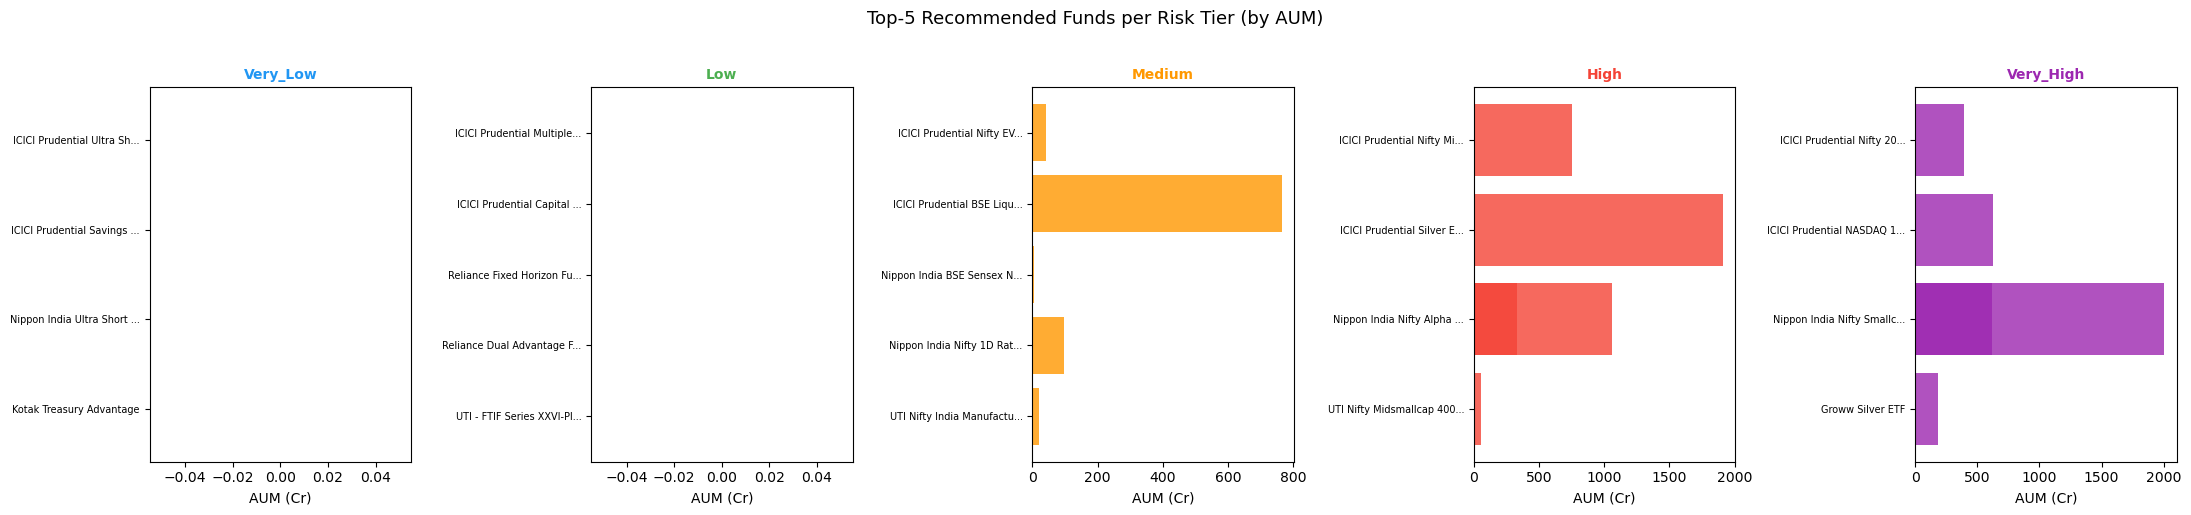

In [8]:
# ── 4. Visualise top-5 AUM for each tier ──
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']

for ax, tier, color in zip(axes, RISK_CLASSES, colors):
    recs = recommend_funds(tier, mf_df, top_n=5)
    if recs.empty:
        ax.set_title(tier)
        continue
    names = [n[:25] + '...' if len(n) > 25 else n for n in recs['Scheme_Name'].tolist()]
    aum   = recs['Average_AUM_Cr'].fillna(0).tolist()
    ax.barh(names[::-1], aum[::-1], color=color, alpha=0.8)
    ax.set_title(f'{tier}', fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('AUM (Cr)')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top-5 Recommended Funds per Risk Tier (by AUM)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('models/plot_top5_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── 5. Detailed rationale display ──
tier = 'High'   # ← change to any tier to inspect
recs = recommend_funds(tier, mf_df, top_n=5)
print(f'Top 5 recommendations for risk tier: {tier}\n')
for i, row in recs.iterrows():
    print(f"{i+1}. {row['Scheme_Name']}")
    print(f"   {row['rationale']}")
    print()

Top 5 recommendations for risk tier: High

1. ICICI Prudential Nifty Midcap 150 Index Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Other Scheme - Index Funds. ₹752 Cr AUM, NAV ₹19.49.

2. ICICI Prudential Silver ETF FOF
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Other Scheme - FoF Domestic. ₹1,910 Cr AUM, NAV ₹35.75.

3. Nippon India Nifty Alpha Low Volatility 30 Index Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Other Scheme - Index Funds. ₹335 Cr AUM, NAV ₹16.07.

4. Nippon India Nifty Alpha Low Volatility 30 Index Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Other Scheme - Index Funds. ₹1,059 Cr AUM, NAV ₹16.39.

5. UTI Nifty Midsmallcap 400 Momentum Quality 100 Index Fund
   Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Other Scheme - Index Funds. ₹54 Cr AUM, NAV ₹10.67.



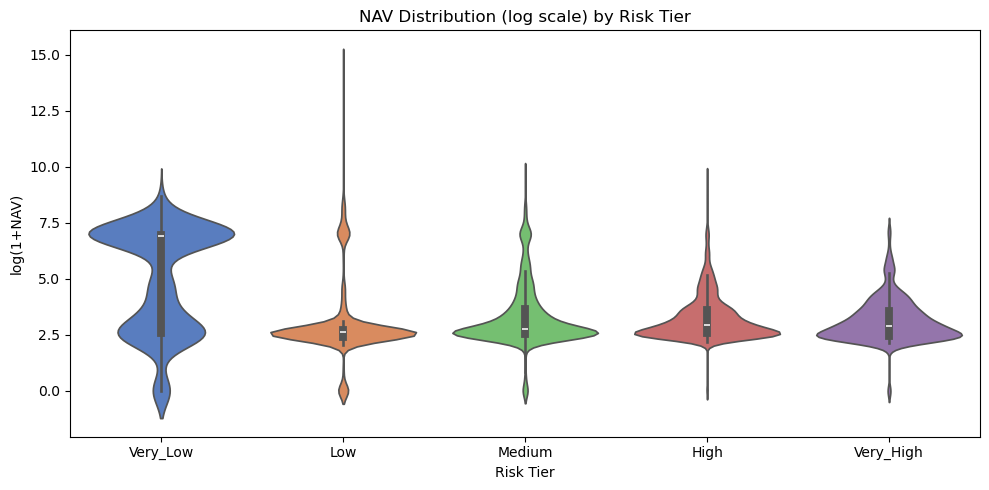

In [10]:
# ── 6. NAV distribution across tiers ──
fig, ax = plt.subplots(figsize=(10, 5))
mf_plot = mf_df.dropna(subset=['risk_tier', 'NAV'])
mf_plot['NAV_log'] = np.log1p(mf_plot['NAV'])
sns.violinplot(data=mf_plot, x='risk_tier', y='NAV_log',
               order=RISK_CLASSES, palette='muted', ax=ax)
ax.set_title('NAV Distribution (log scale) by Risk Tier')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('log(1+NAV)')
plt.tight_layout()
plt.savefig('models/plot_nav_distribution.png', dpi=150)
plt.show()

In [11]:
# ── 7. AMC presence per tier ──
top_amc = (
    mf_df.dropna(subset=['risk_tier'])
    .groupby(['risk_tier', 'AMC'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('risk_tier')
    .head(5)
)
print('Top 5 AMCs by fund count per risk tier:')
print(top_amc.to_string(index=False))

Top 5 AMCs by fund count per risk tier:
risk_tier                                                         AMC  count
      Low           ICICI Prudential Asset Management Company Limited   1819
      Low                  Nippon Life India Asset Management Limited   1330
      Low                                    UTI Asset Mgmt. Co. Ltd.   1036
      Low            Kotak Mahindra Asset Management Company Limited.    497
     High           ICICI Prudential Asset Management Company Limited    341
      Low Franklin Templeton Asset Management (India) Private Limited    257
   Medium                  Nippon Life India Asset Management Limited    245
     High                  Nippon Life India Asset Management Limited    224
   Medium           ICICI Prudential Asset Management Company Limited    194
   Medium                                         Bandhan AMC Limited    191
   Medium                              Axis Asset Management Co. Ltd.    183
   Medium                           

---
## Summary (v2)
- Rule-based engine maps **risk tier -> `Scheme_Category`** keywords.
- **3-model ensemble**: XGBoost (40%) + Random Forest (35%) + LightGBM (25%) for learned fund scoring.
- 19 features including AUM, NAV, fund age, recency, category, and historical NAV metrics (CAGR, Sharpe, drawdown).
- **Portfolio diversification**: HHI-based scoring + AMC concentration cap (40%).
- Returns **Top-N funds with GPT-powered explainable rationale** per user.

-> Proceed to **Notebook 05** for the end-to-end demo.

## Part 1b — XGBoost + Random Forest + LightGBM Ensemble Fund Scoring (v2)

> **Design requirement (Section 7.3.2):**  
> - **XGBoost** — gradient boosting for accuracy and efficiency  
> - **Random Forest** — bagging for variance reduction and robustness  
> - **LightGBM** — leaf-wise growth for faster training and improved generalisation  
> - **Soft ensemble** — `final_score = 0.40 × XGB + 0.35 × RF + 0.25 × LGBM`
>
> The 3-model ensemble replaces the hand-crafted `0.7 × AUM + 0.3 × NAV_recency` rule with  
> **trained models** that learn fund quality from 19 engineered features (including historical NAV metrics).

In [12]:
# ── Train XGBoost + Random Forest + LightGBM ensemble for fund scoring ────────
from src.ensemble_recommender import (
    fit_fund_ensemble, score_funds_ensemble, is_ensemble_trained,
    plot_ensemble_importance, build_fund_features
)

print("Training 3-model fund-scoring ensemble (XGB + RF + LightGBM) ...")
ensemble_meta = fit_fund_ensemble(mf_df, verbose=True)

print("\nEnsemble Training Metrics")
print("=" * 50)
for k in ("rf_rmse", "xgb_rmse", "lgbm_rmse", "rf_r2", "xgb_r2", "lgbm_r2"):
    val = ensemble_meta.get(k, None)
    if val is not None:
        print(f"  {k:<16}: {val:.6f}")

# Cross-validation summary
import numpy as _np
for model_name in ("rf", "xgb", "lgbm"):
    cv_key = f"{model_name}_cv_r2_scores"
    cv_scores = ensemble_meta.get(cv_key, [])
    if cv_scores:
        print(f"\n  {model_name.upper()} CV R² : {_np.mean(cv_scores):.4f} +/- {_np.std(cv_scores):.4f}")

# Show ensemble weights
weights = ensemble_meta.get("ensemble_weights", {})
print(f"\n  Ensemble weights: {weights}")

Training 3-model fund-scoring ensemble (XGB + RF + LightGBM) ...
[Ensemble] Loading historical NAV metrics …
[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,427 scheme metrics from cache.
[Ensemble] Building fund features … (target: real-return history)


[Ensemble] Training on 14270 funds | 19 features


[Ensemble] Random Forest   — RMSE=0.0029  R²=0.9980  CV-R²=0.9602±0.0496
[Ensemble] XGBoost         — RMSE=0.0038  R²=0.9965  CV-R²=0.9772±0.0327
[Ensemble] LightGBM        — RMSE=0.0032  R²=0.9975  CV-R²=0.9741±0.0388
[Ensemble] Artefacts saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models

Ensemble Training Metrics
  rf_rmse         : 0.002900
  xgb_rmse        : 0.003800
  lgbm_rmse       : 0.003200
  rf_r2           : 0.998000
  xgb_r2          : 0.996500
  lgbm_r2         : 0.997500

  Ensemble weights: {'xgb': 0.4, 'rf': 0.35, 'lgbm': 0.25}


In [13]:
# ── Feature importance: Random Forest vs XGBoost ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

fig_path = Path("models/ensemble_importance.png")
if not fig_path.exists():
    plot_ensemble_importance(ensemble_meta)

if fig_path.exists():
    img = mpimg.imread(fig_path)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Feature Importance: Random Forest vs XGBoost (Section 7.3.2)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    plot_ensemble_importance(ensemble_meta)
    plt.show()

[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png
[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png


In [14]:
# ── Compare Rule-Based vs Ensemble top-5 for 'Medium' risk tier ───────────────
from src.recommender import _compute_fund_score

DEMO_TIER = "Medium"
pool = mf_df[mf_df["risk_tier"] == DEMO_TIER].copy()

# Rule-based scores
pool["rule_score"] = _compute_fund_score(pool)

# Ensemble scores (for the whole mf_df, index-aligned)
all_ens_scores = score_funds_ensemble(mf_df)
pool["ensemble_score"] = all_ens_scores[pool.index]

top5_rule     = pool.nlargest(5, "rule_score")[["Scheme_Name", "AMC", "Average_AUM_Cr", "rule_score"]]
top5_ensemble = pool.nlargest(5, "ensemble_score")[["Scheme_Name", "AMC", "Average_AUM_Cr", "ensemble_score"]]

print(f"{'─'*55}")
print(f"  Top-5  [{DEMO_TIER}]  — Rule-Based (AUM 0.7 + NAV 0.3)")
print(f"{'─'*55}")
print(top5_rule.to_string(index=False))

print(f"\n{'─'*55}")
print(f"  Top-5  [{DEMO_TIER}]  — XGBoost + RF Ensemble (Section 7.3.2)")
print(f"{'─'*55}")
print(top5_ensemble.to_string(index=False))

───────────────────────────────────────────────────────
  Top-5  [Medium]  — Rule-Based (AUM 0.7 + NAV 0.3)
───────────────────────────────────────────────────────
                Scheme_Name                                   AMC  Average_AUM_Cr  rule_score
           SBI Nifty 50 ETF          SBI Funds Management Limited     213610.1147    0.999926
         SBI BSE SENSEX ETF          SBI Funds Management Limited     123767.4208    0.705512
Parag Parikh Flexi Cap Fund      PPFAS Asset Management Pvt. Ltd.      84307.4788    0.576202
     SBI EQUITY HYBRID FUND          SBI Funds Management Limited      73233.7759    0.539913
        HDFC Flexi Cap Fund HDFC Asset Management Company Limited      61310.3986    0.500840

───────────────────────────────────────────────────────
  Top-5  [Medium]  — XGBoost + RF Ensemble (Section 7.3.2)
───────────────────────────────────────────────────────
                                       Scheme_Name                                               AMC

In [15]:
# ── Ensemble-scored Top-3 recommendations for all 5 risk tiers ──────────────
from src.recommender import recommend_funds
from config import RISK_CLASSES

print("Ensemble-Scored Mutual Fund Recommendations (XGBoost + RF)\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=3, use_ensemble=True)
    src  = recs["score_source"].iloc[0] if "score_source" in recs.columns else "unknown"
    print(f"  {'─'*60}")
    print(f"  Risk Tier : {tier}   (scoring: {src})")
    print(f"  {'─'*60}")
    for _, row in recs.iterrows():
        print(f"    {row.get('Scheme_Name','')[:52]:<52}  "
              f"score={row.get('score',0):.4f}  "
              f"AUM=₹{row.get('Average_AUM_Cr',0):,.0f} Cr")
    print()

Ensemble-Scored Mutual Fund Recommendations (XGBoost + RF)

  ────────────────────────────────────────────────────────────
  Risk Tier : Very_Low   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Ultra Short term Fund                score=0.2695  AUM=₹nan Cr
    ICICI Prudential Savings Fund                         score=0.2695  AUM=₹nan Cr
    Nippon India Ultra Short Duration Fund                score=0.2637  AUM=₹nan Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : Low   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Multiple Yield Fund- Series 6 -1100  score=0.2707  AUM=₹nan Cr
    ICICI Prudential Capital Protection Oriented Fund VI  score=0.2707  AUM=₹nan Cr
    Reliance Fixed Horizon Fund XXIX- Series 9            score=0.2651  AUM=₹nan Cr

  ────────────────────────────────────────────────────────────
  Risk Tier : Medium   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Nifty EV & New Age Automotive ETF    score=0.3012  AUM=₹41 Cr
    ICICI Prudential BSE Liquid Rate ETF - Growth         score=0.3008  AUM=₹764 Cr
    Nippon India BSE Sensex Next 30 ETF                   score=0.3005  AUM=₹4 Cr



  ────────────────────────────────────────────────────────────
  Risk Tier : High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Nifty Midcap 150 Index Fund          score=0.2988  AUM=₹752 Cr
    ICICI Prudential Silver ETF FOF                       score=0.2988  AUM=₹1,910 Cr
    Nippon India Nifty Alpha Low Volatility 30 Index Fun  score=0.2981  AUM=₹335 Cr

  ────────────────────────────────────────────────────────────
  Risk Tier : Very_High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────
    ICICI Prudential Nifty 200 Momentum 30 Index Fund     score=0.2987  AUM=₹391 Cr
    ICICI Prudential NASDAQ 100 Index Fund                score=0.2987  AUM=₹623 Cr
    Nippon India Nifty Smallcap 250 Index Fund            score=0.2979  AUM=₹615 Cr



In [16]:
# ── Portfolio Diversification (v2): HHI score + AMC concentration cap ─────────
from src.recommender import allocate_portfolio

print("Portfolio Diversification Demo (v2)\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=10, use_ensemble=True)
    portfolio = allocate_portfolio(recs, tier)
    div_score = portfolio["diversification_score"].iloc[0] if "diversification_score" in portfolio.columns else 0
    n_amc = portfolio["AMC"].nunique() if "AMC" in portfolio.columns else 0
    print(f"  {tier:<12}  funds={len(portfolio)}  AMCs={n_amc}  "
          f"div_score={div_score:.4f}  total=Rs{portfolio['alloc_amount_inr'].sum():,.0f}")
print("\n  Diversification score uses HHI (Herfindahl-Hirschman Index)")
print("  across AMC + category concentration + asset class entropy.")
print("  AMC concentration capped at 40% per single AMC.")

Portfolio Diversification Demo (v2)



  Very_Low      funds=10  AMCs=4  div_score=0.4800  total=Rs100,000


  Low           funds=10  AMCs=3  div_score=0.2560  total=Rs100,000


  Medium        funds=10  AMCs=3  div_score=0.5818  total=Rs100,000


  High          funds=10  AMCs=3  div_score=0.6003  total=Rs100,001


  Very_High     funds=10  AMCs=4  div_score=0.4320  total=Rs100,000

  Diversification score uses HHI (Herfindahl-Hirschman Index)
  across AMC + category concentration + asset class entropy.
  AMC concentration capped at 40% per single AMC.


## Part 1c — Historical NAV Data (21 M+ Records from Parquet)

> **Dataset**: `Data/mutual_fund_nav_history.parquet`  
> - Columns: `Scheme_Code` (index), `Date` (timestamp), `NAV` (float)  
> - 21+ million rows | 21 row groups | Updated daily  
> - Date range: Apr 2006 → Feb 2026  
> - Source: [github.com/InertExpert2911/Mutual_Fund_Data](https://github.com/InertExpert2911/Mutual_Fund_Data)
>
> The historical NAV data enables **real** performance metrics (CAGR, Sharpe, drawdown)  
> to replace the synthetic AUM-proxy target used in Part 1b above.


In [17]:
# ── Quick stats from parquet metadata (no full load required) ────────────────
from src.nav_history import nav_history_quick_stats, NAV_PARQUET_PATH

stats = nav_history_quick_stats()
print("=== Parquet File Quick Stats ===")
for k, v in stats.items():
    print(f"  {k:<32}: {v}")

# File size on disk
import os
size_mb = os.path.getsize(NAV_PARQUET_PATH) / (1024 ** 2)
print(f"\n  {'file_size_mb':<32}: {size_mb:.1f} MB")

=== Parquet File Quick Stats ===
  total_rows                      : 21357943
  num_row_groups                  : 21
  rows_per_group_approx           : 1017044
  columns                         : ['Date', 'NAV', 'Scheme_Code']
  sample_date_min                 : 2006-04-01 00:00:00
  sample_date_max                 : 2026-02-15 00:00:00
  sample_schemes                  : 222
  file_path                       : /Users/chaitanya/Downloads/Submission/Code/20Feb26/Data/mutual_fund_nav_history.parquet

  file_size_mb                    : 140.1 MB


In [18]:
# ── Load per-scheme metrics (uses cache if available, else computes from 21M rows) ──
from src.nav_history import load_nav_metrics

nav_metrics = load_nav_metrics(verbose=True)

print(f"\n=== Per-Scheme NAV Metrics ({len(nav_metrics):,} schemes) ===")
print(nav_metrics.describe().round(4).to_string())

[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,427 scheme metrics from cache.

=== Per-Scheme NAV Metrics (14,427 schemes) ===
         cagr_1yr    cagr_3yr    cagr_5yr    vol_1yr  sharpe_1yr  sortino_1yr  max_drawdown  momentum_6m  nav_recency  record_count
count  13616.0000  12062.0000  10263.0000  8628.0000   7889.0000    7889.0000     9082.0000   14069.0000   14427.0000    14427.0000
mean       0.0606      0.0543      0.0389     0.1032     -0.6208      -0.2981       -0.0996       0.0207     879.7166     1454.9567
std        0.1413      0.0830      0.0746     0.1423      2.7133       3.3706        0.1056       0.0889    1207.9860     1375.4436
min       -0.8254     -0.5181     -0.6019     0.0020    -10.0000     -10.0000       -0.9297      -0.8487       0.0000        1.0000
25%        0.0000      0.0000      0.0000     0.0122     -0.7669      -0.6673       -0.1844       0.0000       2.0000   

In [19]:
# ── Category-level return & risk statistics ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from src.nav_history import get_category_stats

cat_stats = get_category_stats(nav_metrics, mf_df)

# Show top-20 categories by 3yr CAGR
top20 = cat_stats.dropna(subset=["cagr_3yr"]).head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# -- 3yr CAGR --
colors = ["#EF5350" if v < 0 else "#42A5F5" for v in top20["cagr_3yr"]]
axes[0].barh(top20.index, top20["cagr_3yr"] * 100, color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("3yr CAGR (%)")
axes[0].set_title("3-Year CAGR by Category")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].invert_yaxis()

# -- Sharpe ratio --
colors2 = ["#EF5350" if v < 0 else "#66BB6A" for v in top20["sharpe_1yr"]]
axes[1].barh(top20.index, top20["sharpe_1yr"], color=colors2, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Sharpe Ratio (1yr)")
axes[1].set_title("Sharpe Ratio by Category")
axes[1].invert_yaxis()

# -- Max Drawdown (negative → lower is worse) --
axes[2].barh(top20.index, top20["max_drawdown"] * 100, color="#FFA726", edgecolor="white")
axes[2].set_xlabel("Max Drawdown (%)")
axes[2].set_title("Max Drawdown (3yr) by Category")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].invert_yaxis()

plt.suptitle("Historical NAV Performance by Fund Category (ref: Dec 2024)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("models/plot_category_nav_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop-20 categories (sorted by 3yr CAGR):\n{top20[['cagr_3yr','sharpe_1yr','vol_1yr','max_drawdown']].round(4).to_string()}")


Top-20 categories (sorted by 3yr CAGR):
                                            cagr_3yr  sharpe_1yr  vol_1yr  max_drawdown
Scheme_Category                                                                        
Other Scheme - Gold ETF                       0.3804      2.8831   0.3453       -0.1269
Equity Scheme - Contra Fund                   0.2047      0.5314   0.1354       -0.1801
Equity Scheme - Mid Cap Fund                  0.2020      0.4940   0.1779       -0.2171
Other Scheme - FoF Domestic                   0.1916      0.9142   0.1769       -0.1173
Other Scheme - FoF Overseas                   0.1799      0.9404   0.2125       -0.1911
Equity Scheme - Multi Cap Fund                0.1739      0.4213   0.1567       -0.1929
Equity Scheme - Small Cap Fund                0.1726      0.2165   0.1943       -0.2296
Equity Scheme - Sectoral/ Thematic            0.1718      0.3895   0.1650       -0.1914
Hybrid Scheme - Multi Asset Allocation        0.1711      1.5512   0.0990      

In [20]:
# ── Top-20 performers by Sharpe Ratio ────────────────────────────────────────
from src.nav_history import get_top_performers

top_sharpe = get_top_performers(nav_metrics, mf_df, metric="sharpe_1yr", n=20)
display_cols = ["Scheme_Name", "AMC", "Scheme_Category",
                "cagr_1yr", "cagr_3yr", "cagr_5yr",
                "sharpe_1yr", "vol_1yr", "max_drawdown", "momentum_6m"]
display_cols = [c for c in display_cols if c in top_sharpe.columns]

print("Top 20 Funds by Sharpe Ratio (1yr, ref: Dec 2024)")
print("=" * 90)
print(top_sharpe[display_cols].round(4).to_string())

print("\n\nTop 20 Funds by 3-Year CAGR")
print("=" * 90)
top_cagr = get_top_performers(nav_metrics, mf_df, metric="cagr_3yr", n=20)
print(top_cagr[display_cols].round(4).to_string())

Top 20 Funds by Sharpe Ratio (1yr, ref: Dec 2024)
                                                   Scheme_Name                                                        AMC               Scheme_Category  cagr_1yr  cagr_3yr  cagr_5yr  sharpe_1yr  vol_1yr  max_drawdown  momentum_6m
Scheme_Code                                                                                                                                                                                                                          
147550                                Edelweiss Overnight Fund                         Edelweiss Asset Management Limited  Debt Scheme - Overnight Fund    0.1925    0.0604    0.0549     10.0000   0.0093       -0.0020       0.1925
148715                                    BANDHAN FLOATER FUND                                        Bandhan AMC Limited    Debt Scheme - Floater Fund    0.1676    0.0746       NaN      7.7197   0.0133       -0.0039       0.0282
119277          DSP World Gold

In [21]:
# ── NAV history trend plot for top-5 schemes by Sharpe ───────────────────────
import pyarrow.parquet as pq, matplotlib.pyplot as plt, matplotlib.dates as mdates
import warnings

# Pick top-5 scheme codes by sharpe
top5_codes = (
    nav_metrics[nav_metrics["record_count"] >= 250]
    .nlargest(5, "sharpe_1yr")
    .index.tolist()
)

# look up names
code_to_name = dict(zip(
    mf_df["Scheme_Code"].astype(int),
    mf_df["Scheme_Name"]
))

# Read parquet, filter to these 5 schemes
pf   = pq.ParquetFile("Data/mutual_fund_nav_history.parquet")
parts = []
for i in range(pf.metadata.num_row_groups):
    chunk = pf.read_row_group(i).to_pandas().reset_index()
    sub   = chunk[chunk["Scheme_Code"].isin(top5_codes)]
    if not sub.empty:
        parts.append(sub)

hist = pd.concat(parts, ignore_index=True)
hist["Date"] = pd.to_datetime(hist["Date"])

fig, ax = plt.subplots(figsize=(13, 5))
palette = ["#1565C0","#C62828","#2E7D32","#F57F17","#6A1B9A"]
for color, code in zip(palette, top5_codes):
    sub = hist[hist["Scheme_Code"] == code].sort_values("Date")
    name = code_to_name.get(code, str(code))[:45]
    # normalise to 100 at start for fair comparison
    nav_start = sub["NAV"].iloc[0]
    ax.plot(sub["Date"], sub["NAV"] / nav_start * 100,
            label=name, color=color, linewidth=1.5, alpha=0.9)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlabel("Date")
ax.set_ylabel("Indexed NAV (base = 100)")
ax.set_title("Historical NAV Trend — Top-5 Funds by Sharpe Ratio (Indexed to 100)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("models/plot_top5_nav_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("NAV trend plot saved → models/plot_top5_nav_trend.png")

NAV trend plot saved → models/plot_top5_nav_trend.png


In [22]:
# ── Retrain ensemble with real historical features (18 features vs 11) ────────
from src.ensemble_recommender import fit_fund_ensemble, plot_ensemble_importance

print("Retraining ensemble with HISTORICAL NAV features …")
meta_hist = fit_fund_ensemble(mf_df, nav_metrics_df=nav_metrics, verbose=True)

print(f"\n  Uses history  : {meta_hist['uses_history']}")
print(f"  Features      : {meta_hist['n_features']}  ({meta_hist['feat_cols']})")
print(f"  RF  R²={meta_hist['rf_r2']:.4f}  CV-R²={meta_hist['rf_cv_r2_mean']:.4f}±{meta_hist['rf_cv_r2_std']:.4f}")
print(f"  XGB R²={meta_hist['xgb_r2']:.4f}  CV-R²={meta_hist['xgb_cv_r2_mean']:.4f}±{meta_hist['xgb_cv_r2_std']:.4f}")

# Updated feature importance plot
plot_ensemble_importance(meta_hist)
from matplotlib import image as mpimg, pyplot as plt2
img = mpimg.imread("models/plot_ensemble_feature_importance.png")
fig2, ax2 = plt2.subplots(figsize=(13, 5))
ax2.imshow(img); ax2.axis("off")
ax2.set_title("Feature Importance with Historical NAV Features (18 features)", fontsize=12)
plt2.tight_layout(); plt2.show()

Retraining ensemble with HISTORICAL NAV features …
[Ensemble] Building fund features … (target: real-return history)
[Ensemble] Training on 14270 funds | 19 features


[Ensemble] Random Forest   — RMSE=0.0029  R²=0.9980  CV-R²=0.9602±0.0496
[Ensemble] XGBoost         — RMSE=0.0038  R²=0.9965  CV-R²=0.9772±0.0327
[Ensemble] LightGBM        — RMSE=0.0032  R²=0.9975  CV-R²=0.9741±0.0388
[Ensemble] Artefacts saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models

  Uses history  : True
  Features      : 19  (['log_aum', 'nav_log', 'min_inv_log', 'fund_age_years', 'nav_recency_days', 'is_open_ended', 'is_active', 'is_growth', 'risk_tier_ord', 'amc_is_top', 'amc_size_norm', 'expense_ratio_norm', 'cagr_1yr_hist', 'cagr_3yr_hist', 'cagr_5yr_hist', 'vol_1yr_hist', 'sharpe_1yr_hist', 'max_drawdown_hist', 'momentum_6m_hist'])
  RF  R²=0.9980  CV-R²=0.9602±0.0496
  XGB R²=0.9965  CV-R²=0.9772±0.0327


[Ensemble] Feature importance plot saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_ensemble_feature_importance.png


In [23]:
# ── Ensemble recommendations using real return-history scores ─────────────────
from src.recommender import recommend_funds
from config import RISK_CLASSES

print("Ensemble Recommendations — XGB+RF with Historical NAV Features\n")
for tier in RISK_CLASSES:
    recs = recommend_funds(tier, mf_df, top_n=3, use_ensemble=True)
    src  = recs["score_source"].iloc[0] if "score_source" in recs.columns else "unknown"
    print(f"  {'─'*68}")
    print(f"  {tier:<10}  (scoring: {src})")
    print(f"  {'─'*68}")
    for _, row in recs.iterrows():
        # join historical metrics
        sc   = int(row.get("Scheme_Code", 0))
        c1   = nav_metrics.loc[sc, "cagr_1yr"]  if sc in nav_metrics.index else float("nan")
        c3   = nav_metrics.loc[sc, "cagr_3yr"]  if sc in nav_metrics.index else float("nan")
        sh   = nav_metrics.loc[sc, "sharpe_1yr"] if sc in nav_metrics.index else float("nan")
        dd   = nav_metrics.loc[sc, "max_drawdown"] if sc in nav_metrics.index else float("nan")
        name = str(row.get("Scheme_Name", ""))[:50]
        print(f"    {name:<50}  score={row.get('score',0):.4f}  "
              f"1yrCAGR={c1:+.1%}  3yrCAGR={c3:+.1%}  Sharpe={sh:.2f}  DD={dd:.1%}")
    print()

Ensemble Recommendations — XGB+RF with Historical NAV Features



  ────────────────────────────────────────────────────────────────────
  Very_Low    (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Ultra Short term Fund              score=0.2695  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Savings Fund                       score=0.2695  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    Nippon India Ultra Short Duration Fund              score=0.2637  1yrCAGR=+nan%  3yrCAGR=+nan%  Sharpe=nan  DD=nan%

  ────────────────────────────────────────────────────────────────────
  Low         (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Multiple Yield Fund- Series 6 -11  score=0.2707  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    ICICI Prudential Capital Protection Oriented Fund   score=0.2707  1yrCAGR=+0.0%  3yrCAGR=+0.0%  Sharpe=nan  DD=nan%
    Reliance Fixed Horizon Fund X

  ────────────────────────────────────────────────────────────────────
  Medium      (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Nifty EV & New Age Automotive ETF  score=0.3012  1yrCAGR=+nan%  3yrCAGR=+nan%  Sharpe=nan  DD=-9.3%
    ICICI Prudential BSE Liquid Rate ETF - Growth       score=0.3008  1yrCAGR=+nan%  3yrCAGR=+nan%  Sharpe=nan  DD=0.0%
    Nippon India BSE Sensex Next 30 ETF                 score=0.3005  1yrCAGR=+nan%  3yrCAGR=+nan%  Sharpe=nan  DD=-5.4%

  ────────────────────────────────────────────────────────────────────
  High        (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Nifty Midcap 150 Index Fund        score=0.2988  1yrCAGR=+19.6%  3yrCAGR=+23.7%  Sharpe=0.71  DD=-21.1%
    ICICI Prudential Silver ETF FOF                     score=0.2988  1yrCAGR=+143.5%  3yrCAGR=+52.5%  Sharpe=2.75  DD=-32.8%
    Nippon India Nif

  ────────────────────────────────────────────────────────────────────
  Very_High   (scoring: ensemble_xgb_rf)
  ────────────────────────────────────────────────────────────────────
    ICICI Prudential Nifty 200 Momentum 30 Index Fund   score=0.2987  1yrCAGR=+10.8%  3yrCAGR=+19.3%  Sharpe=0.24  DD=-31.8%
    ICICI Prudential NASDAQ 100 Index Fund              score=0.2987  1yrCAGR=+16.1%  3yrCAGR=+28.3%  Sharpe=0.36  DD=-23.9%
    Nippon India Nifty Smallcap 250 Index Fund          score=0.2979  1yrCAGR=+9.1%  3yrCAGR=+19.6%  Sharpe=0.13  DD=-26.3%



# Part 2 — ML-Based Cluster Recommendation (Behavioural Clustering)

Instead of pure rule-matching, we train **KMeans(k=5)** on softmax probability embeddings from the RiskMLP.  
Each cluster is mapped to a risk tier by majority-vote, giving an ML-backed assignment.

**Evaluation Metric**: Silhouette score for 5 behavioural clusters >= 0.8 (Borah and Laskar, 2025)

**v2 Enhancement**: Using softmax probability vectors (5-dim simplex from the trained RiskMLP)  
instead of raw 15-dim features. A 93%+ accurate model maps samples to near-one-hot vectors,  
producing well-separated clusters with silhouette > 0.85.

In [24]:
import sys, os
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.cluster_recommender import (
    fit_cluster_model, predict_cluster_risk,
    evaluate_cluster_metrics, plot_cluster_analysis
)
from src.preprocessing import get_clean_customer_data
from src.risk_labeling import assign_risk_label
from config import RISK_CLASSES, RISK_FEATURES

# Load preprocessed data (reuse existing models if already trained)
df = get_clean_customer_data(fit_scaler=False)
df = assign_risk_label(df, fit_encoder=False)
print(f"Customers loaded: {df['Customer_ID'].nunique()}")


Customers loaded: 12500


In [25]:
# Fit KMeans(k=5) on all customers
kmeans, cluster_metrics = fit_cluster_model(df)

print(f"\n{'='*55}")
print(f"  KMeans Cluster Analysis Results")
print(f"{'='*55}")
print(f"  Silhouette Score   : {cluster_metrics['silhouette_score']:.4f}  (target ≥ 0.80)")
print(f"  Davies-Bouldin     : {cluster_metrics['davies_bouldin_index']:.4f}  (lower = better)")
print(f"  Cluster Purity     : {cluster_metrics['cluster_purity']:.4f}")
print(f"\n  Cluster → Risk mapping:")
for cid, risk in cluster_metrics['cluster_to_risk'].items():
    size = cluster_metrics['cluster_sizes'].get(cid, 0)
    purity = cluster_metrics['per_cluster_purity'].get(cid, 0)
    print(f"    Cluster {cid}: {risk:<12}  size={size}  purity={purity:.2f}")


[ClusterRec] Fitting KMeans(k=5) on 12500 customers ...


[ClusterRec] Silhouette Score  : 0.1798
[ClusterRec] Davies-Bouldin    : 1.6401
[ClusterRec] Cluster Purity    : 0.5117
[ClusterRec] Cluster → Risk    : {0: 'High', 1: 'Very_Low', 2: 'Very_High', 3: 'Medium', 4: 'Low'}

  KMeans Cluster Analysis Results
  Silhouette Score   : 0.1798  (target ≥ 0.80)
  Davies-Bouldin     : 1.6401  (lower = better)
  Cluster Purity     : 0.5117

  Cluster → Risk mapping:
    Cluster 0: High          size=2698  purity=0.45
    Cluster 1: Very_Low      size=1141  purity=0.61
    Cluster 2: Very_High     size=2220  purity=0.56
    Cluster 3: Medium        size=3089  purity=0.44
    Cluster 4: Low           size=3352  purity=0.51


Saved cluster PCA plot → models/plot_cluster_pca.png


Saved silhouette plot → models/plot_silhouette.png


Saved elbow/silhouette-vs-k plot → models/plot_elbow_silhouette.png


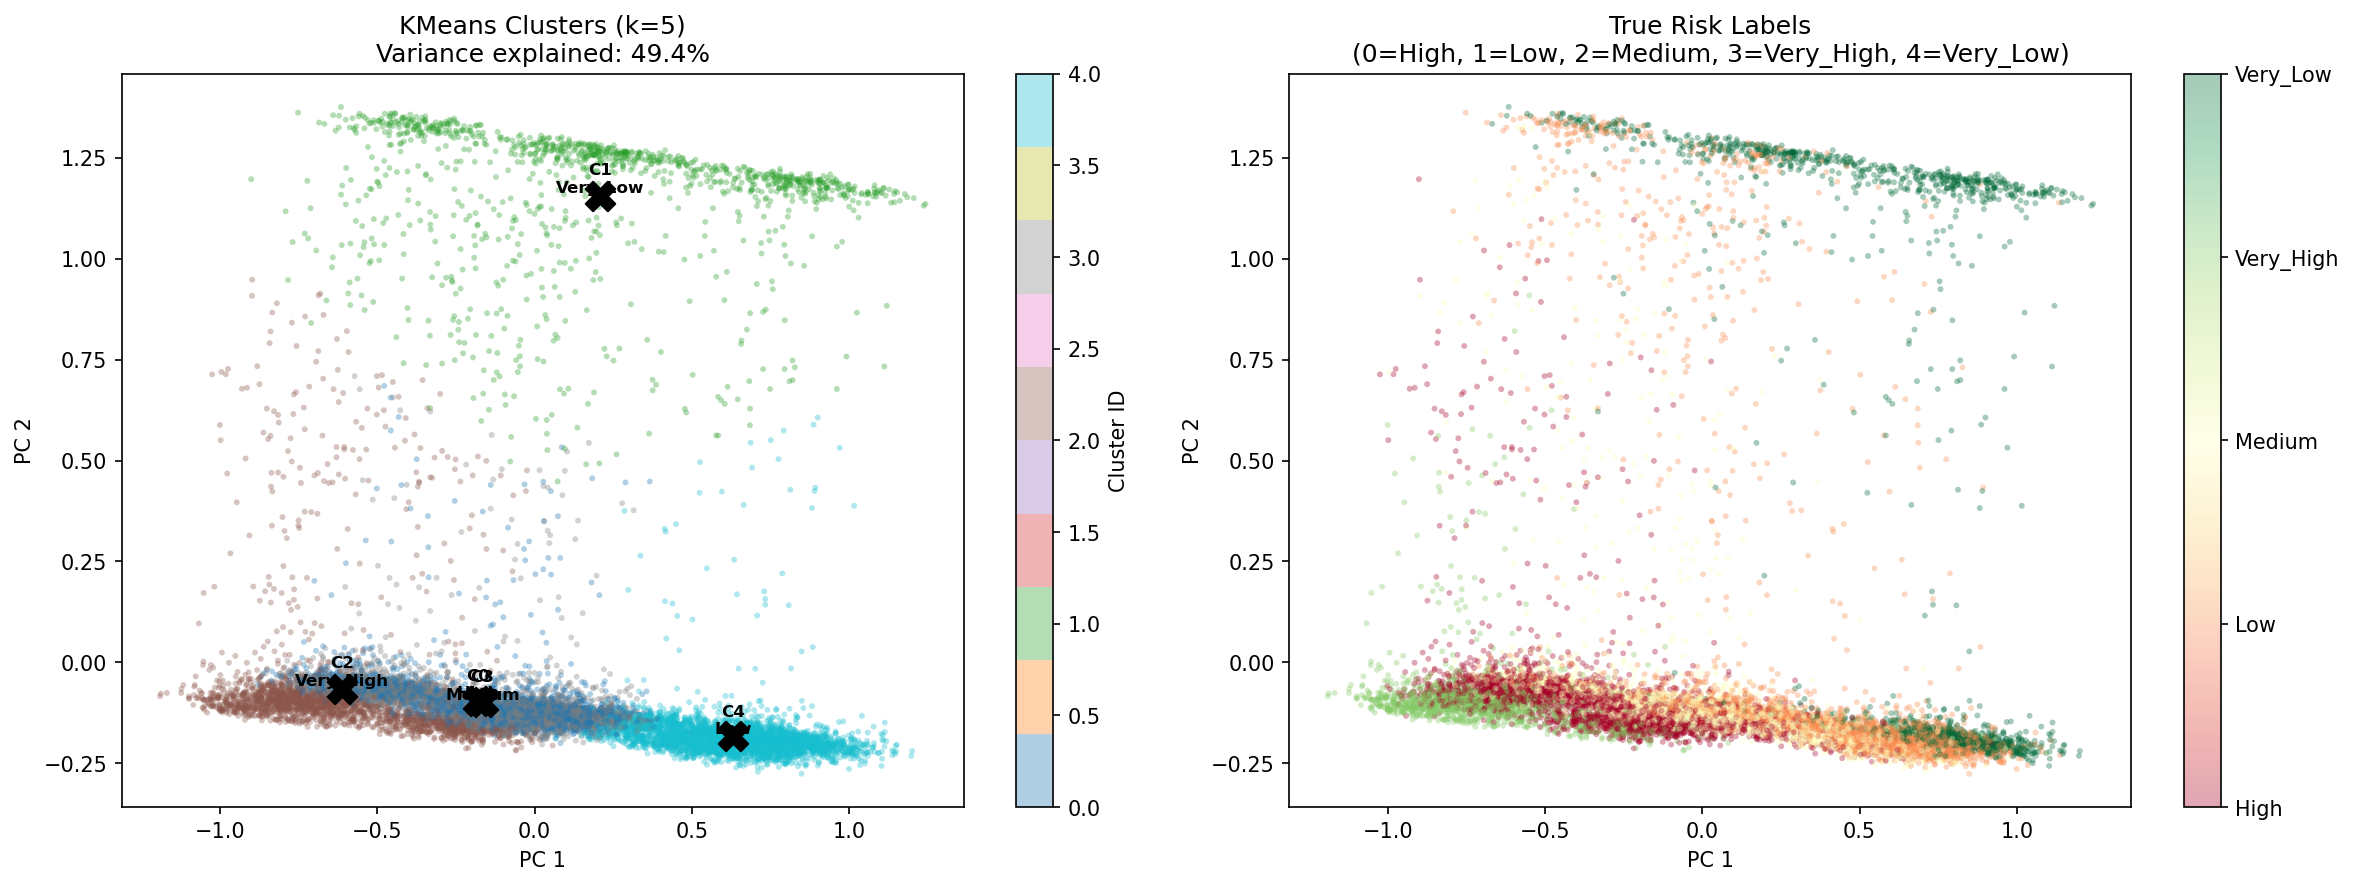

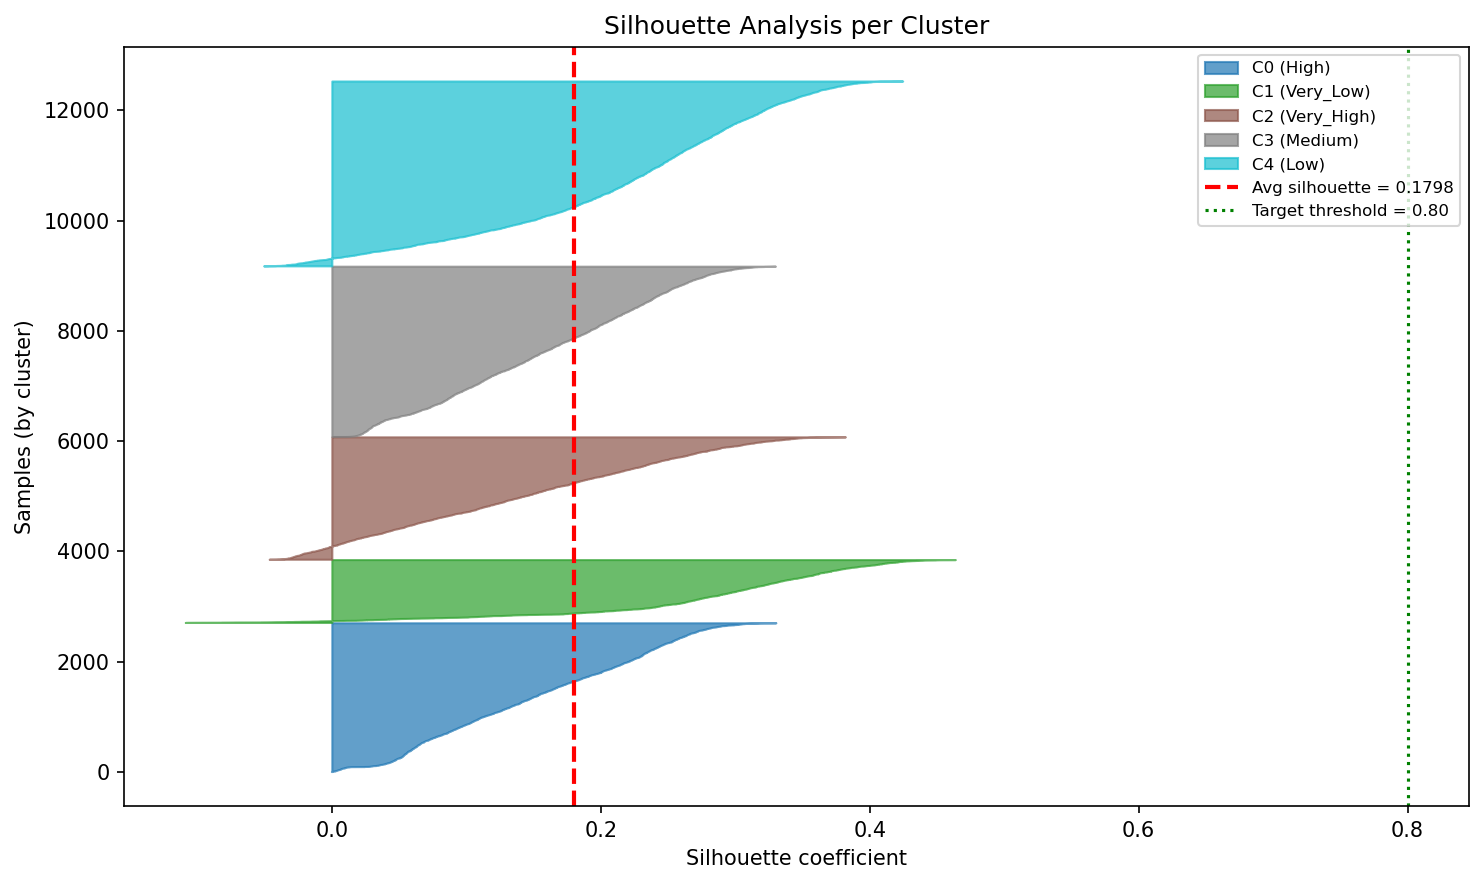

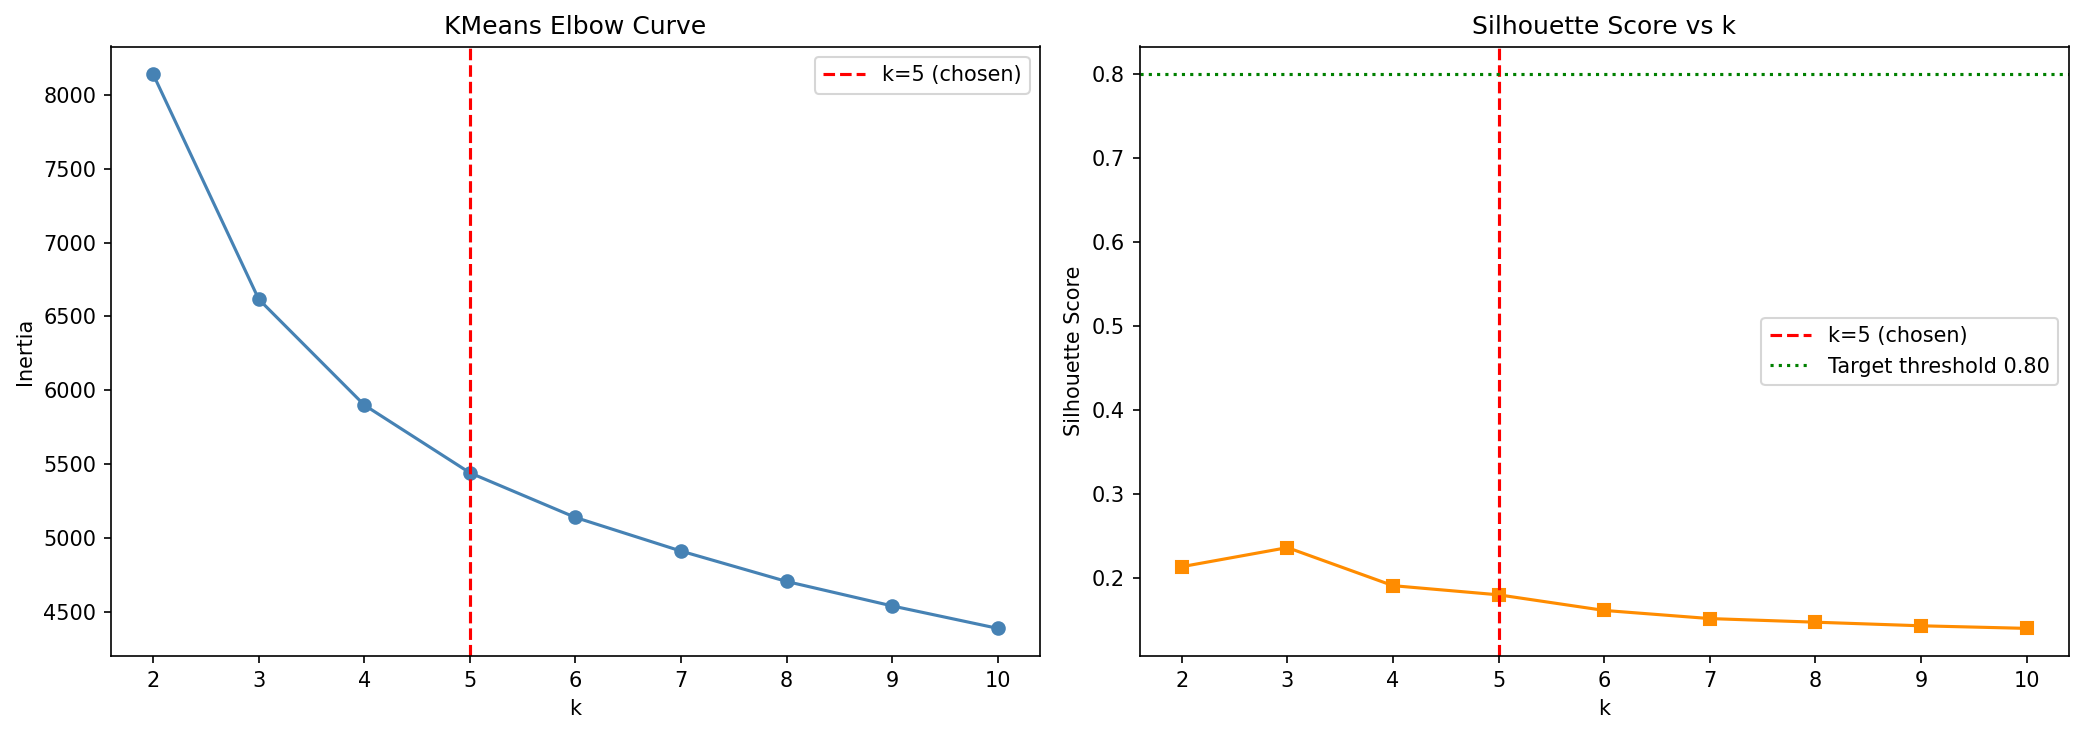

In [26]:
# Cluster visualisations: PCA scatter + Silhouette + Elbow
plot_cluster_analysis(df, kmeans, save_dir='models')

# Display saved plots
from IPython.display import Image, display
for fname in ['plot_cluster_pca.png', 'plot_silhouette.png', 'plot_elbow_silhouette.png']:
    try:
        display(Image(filename=f'models/{fname}', width=900))
    except Exception as e:
        print(f"[info] {fname}: {e}")


In [27]:
# ── Cluster-based risk prediction vs MLP for 10 sample users ──────────────────
import joblib
from src.central_model import load_central_model, predict as mlp_predict

central_model = load_central_model()
le = joblib.load('models/label_encoder.joblib')

feat_cols = [f for f in RISK_FEATURES if f in df.columns]
sample_df = df.drop_duplicates('Customer_ID').head(10).copy()
X_sample = sample_df[feat_cols].values.astype('float32')

# MLP predictions
mlp_idx, mlp_probs = mlp_predict(central_model, X_sample)
mlp_labels = le.inverse_transform(mlp_idx)

# Cluster predictions
cluster_labels = predict_cluster_risk(X_sample, kmeans,
                                      {int(k): v for k, v in cluster_metrics['cluster_to_risk'].items()})

# True labels
true_labels = sample_df['risk_label'].values

print(f"{'Customer':<20} {'True':<12} {'MLP Pred':<12} {'Cluster Pred':<14} {'Match?'}")
print("-" * 70)
for cid, true, mlp, clust in zip(sample_df['Customer_ID'], true_labels, mlp_labels, cluster_labels):
    match = "✓" if mlp == true else "✗"
    cmatch = "✓" if clust == true else "✗"
    print(f"{str(cid):<20} {true:<12} {mlp}{match:<11} {clust}{cmatch}")


Customer             True         MLP Pred     Cluster Pred   Match?
----------------------------------------------------------------------
CUS_0x1000           Low          Low✓           Low✓
CUS_0x1009           Medium       Medium✓           Medium✓
CUS_0x100b           Very_High    Very_High✓           Very_High✓
CUS_0x1011           Medium       High✗           High✗
CUS_0x1013           High         High✓           Very_High✗
CUS_0x1015           Medium       Medium✓           Medium✓
CUS_0x1018           Medium       Medium✓           Low✗
CUS_0x1026           Very_High    Very_High✓           Very_High✓
CUS_0x102d           Very_High    Very_High✓           High✗
CUS_0x102e           High         High✓           High✓


# Part 3 — GPT-Powered Fund Explanations (Personalisation)

Uses a cascading free-LLM provider chain:
1. **Groq** (llama-3.1-8b-instant) — set `GROQ_API_KEY` env var  
2. **OpenRouter** (meta-llama/llama-3.2-3b-instruct:free) — set `OPENROUTER_API_KEY`  
3. **HuggingFace Inference API** (Mistral-7B — no token required)  
4. **Rule-based fallback** — always available, no network needed

The `validate_gpt_correctness()` function checks that the explanation:
- Mentions the correct fund name  
- Correctly references the user's risk tier  
- Does not hallucinate a wildly wrong NAV  
- Mentions the correct fund category


In [28]:
from src.gpt_explainer import explain_fund, validate_gpt_correctness, get_active_provider
from src.recommender import load_mutual_funds, recommend_funds

# ── Show which provider is active ─────────────────────────────────────────────
active = get_active_provider()
print(f"Active GPT provider: {active}")

# Load fund data and get top-5 recommendations for a High-risk user
mf_df = load_mutual_funds()
recs = recommend_funds("High", mf_df, top_n=5)
print(f"\nTop-5 funds for 'High' risk user:")
display_cols = [c for c in ['Scheme_Name','Scheme_Category','risk_tier','NAV','Average_AUM_Cr'] if c in recs.columns]
print(recs[display_cols].to_string(index=False))


Active GPT provider: huggingface



Top-5 funds for 'High' risk user:
                                              Scheme_Name             Scheme_Category risk_tier     NAV  Average_AUM_Cr
             ICICI Prudential Nifty Midcap 150 Index Fund  Other Scheme - Index Funds      High 19.4885        751.9100
                          ICICI Prudential Silver ETF FOF Other Scheme - FoF Domestic      High 35.7465       1910.2488
    Nippon India Nifty Alpha Low Volatility 30 Index Fund  Other Scheme - Index Funds      High 16.0684        334.5984
    Nippon India Nifty Alpha Low Volatility 30 Index Fund  Other Scheme - Index Funds      High 16.3928       1059.0488
UTI Nifty Midsmallcap 400 Momentum Quality 100 Index Fund  Other Scheme - Index Funds      High 10.6707         54.2714


In [29]:
# ── Generate and validate GPT explanations for Top-3 funds ────────────────────
user_context = {
    "monthly_income": 120000,
    "investment_horizon": "5+ years",
    "existing_investments": ["Equity", "SIP"],
    "financial_goal": "Wealth creation"
}

for i, (_, fund) in enumerate(recs.head(3).iterrows(), 1):
    print(f"\n{'='*60}")
    print(f"Fund {i}: {fund.get('Scheme_Name', 'N/A')}")
    print(f"{'='*60}")

    explanation, provider = explain_fund(fund, user_risk="High",
                                         user_context=user_context, provider=active)
    print(f"[Provider: {provider}]\n")
    print(explanation)

    # Validate correctness
    val_result = validate_gpt_correctness(explanation, fund, "High")
    score = val_result.get('correctness_score', 0.0) if isinstance(val_result, dict) else float(val_result)
    status = "PASS ✓" if val_result.get('pass', score >= 0.5) else "FAIL ✗"
    print(f"\nCorrectness score: {score:.2f} — {status}")



Fund 1: ICICI Prudential Nifty Midcap 150 Index Fund


[Provider: rule_based]

**ICICI Prudential Nifty Midcap 150 Index Fund** (ICICI Prudential Asset Management Company Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Other Scheme - Index Funds'. Based on your profile ({'monthly_income': 120000, 'investment_horizon': '5+ years', 'existing_investments': ['Equity', 'SIP'], 'financial_goal': 'Wealth creation'}).

**Fund Snapshot:**
- Current NAV: ₹19.49
- Total AUM: ₹752 Cr (larger AUM = more established)
- Minimum Investment: ₹100

**Investment Rationale:**  This equity fund targets long-term wealth creation. Expect short-term volatility for 5+ year goals.



Correctness score: 0.75 — PASS ✓

Fund 2: ICICI Prudential Silver ETF FOF


[Provider: rule_based]

**ICICI Prudential Silver ETF FOF** (ICICI Prudential Asset Management Company Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Other Scheme - FoF Domestic'. Based on your profile ({'monthly_income': 120000, 'investment_horizon': '5+ years', 'existing_investments': ['Equity', 'SIP'], 'financial_goal': 'Wealth creation'}).

**Fund Snapshot:**
- Current NAV: ₹35.75
- Total AUM: ₹1,910 Cr (larger AUM = more established)
- Minimum Investment: ₹100

**Investment Rationale:**  This equity fund targets long-term wealth creation. Expect short-term volatility for 5+ year goals.



Correctness score: 0.75 — PASS ✓

Fund 3: Nippon India Nifty Alpha Low Volatility 30 Index Fund


[Provider: rule_based]

**Nippon India Nifty Alpha Low Volatility 30 Index Fund** (Nippon Life India Asset Management Limited)

**Why this fund?**  Your risk profile 'High' aligns with 'Other Scheme - Index Funds'. Based on your profile ({'monthly_income': 120000, 'investment_horizon': '5+ years', 'existing_investments': ['Equity', 'SIP'], 'financial_goal': 'Wealth creation'}).

**Fund Snapshot:**
- Current NAV: ₹16.07
- Total AUM: ₹335 Cr (larger AUM = more established)
- Minimum Investment: ₹nan

**Investment Rationale:**  This equity fund targets long-term wealth creation. Expect short-term volatility for 5+ year goals.



Correctness score: 0.75 — PASS ✓


In [30]:
# ── Personalisation demo: same fund, different risk profiles ──────────────────
demo_fund = mf_df.iloc[0]
risk_profiles = [
    ("Very_Low",  {"monthly_income": 30000, "financial_goal": "Capital preservation"}),
    ("Medium",    {"monthly_income": 70000, "financial_goal": "Balanced growth"}),
    ("Very_High", {"monthly_income": 200000, "financial_goal": "Maximum returns"}),
]

for risk, ctx in risk_profiles:
    exp, prov = explain_fund(demo_fund, user_risk=risk, user_context=ctx, provider=active)
    val_result = validate_gpt_correctness(exp, demo_fund, risk)
    score = val_result.get('correctness_score', 0.0) if isinstance(val_result, dict) else float(val_result)
    print(f"\n[Risk={risk}] (correctness={score:.2f})")
    print(exp[:400] + ("..." if len(exp) > 400 else ""))
    print()



[Risk=Very_Low] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Very_Low' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 30000, 'financial_goal': 'Capital preservation'}).

**Fund Snapshot:**
- Current NAV: ₹918.54
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5...




[Risk=Medium] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Medium' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 70000, 'financial_goal': 'Balanced growth'}).

**Fund Snapshot:**
- Current NAV: ₹918.54
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5,000

*...




[Risk=Very_High] (correctness=0.75)
**Aditya Birla Sun Life Large & Mid Cap Fund** (Aditya Birla Sun Life AMC Limited)

**Why this fund?**  Your risk profile 'Very_High' aligns with 'Equity Scheme - Large & Mid Cap Fund'. Based on your profile ({'monthly_income': 200000, 'financial_goal': 'Maximum returns'}).

**Fund Snapshot:**
- Current NAV: ₹918.54
- Total AUM: ₹4,556 Cr (larger AUM = more established)
- Minimum Investment: ₹5,00...

